In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression,Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [2]:
X, y = make_regression(n_samples = 100, n_features = 1, n_informative = 1, n_targets = 1, noise = 20, random_state = 13)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

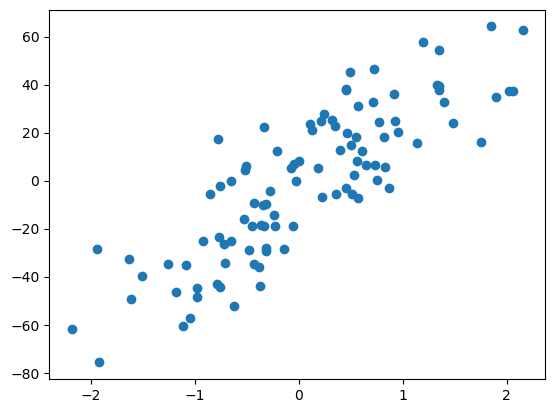

In [4]:
plt.scatter(X,y)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [6]:
print(lr.coef_)
print(lr.intercept_)

[26.36925897]
-1.918391533404907


C:\Users\Om\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Om\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Om\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.139e+04, tolerance: 6.443e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

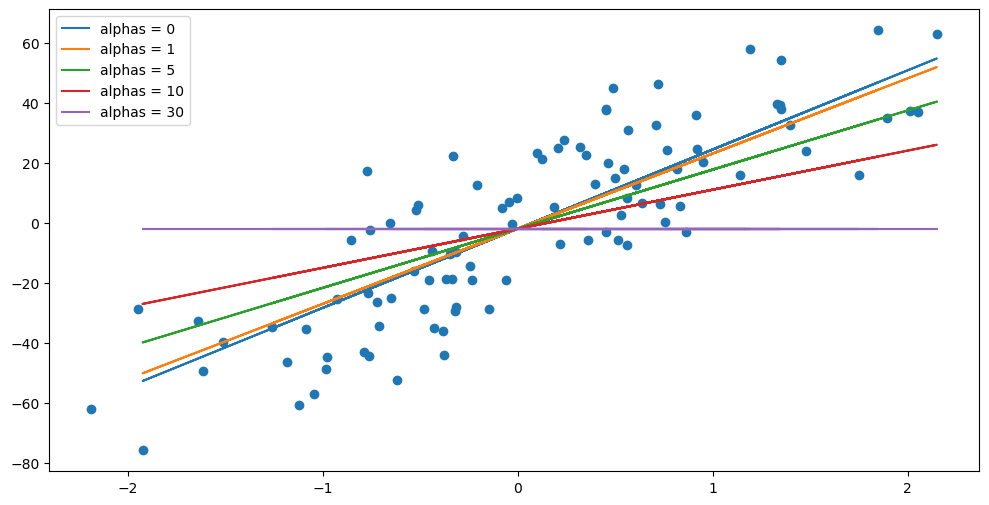

In [7]:
alphas = [0,1,5,10,30]

plt.figure(figsize=(12,6))
plt.scatter(X, y)

for i in alphas:
    l = Lasso(alpha = i)
    l.fit(X_train, y_train)
    plt.plot(X_test, l.predict(X_test), label = f'alphas = {i}')

plt.legend()
plt.show()

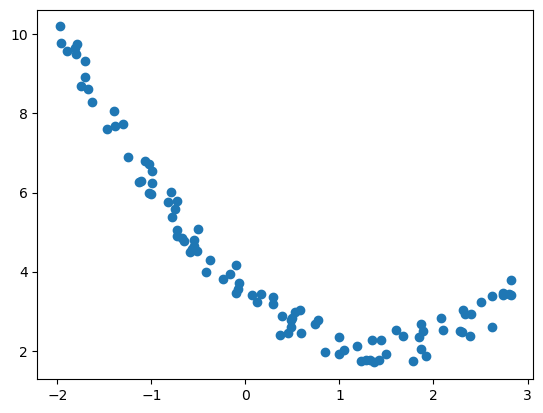

In [8]:
m = 100
x1 = 5 * np.random.rand(m, 1) -2
x2 = 0.7 * x1 ** 2 -2 * x1+ 3 + np.random.rand(m, 1)

plt.scatter(x1, x2)
plt.show()

C:\Users\Om\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\Om\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\Om\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.161e+00, tolerance: 5.496e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

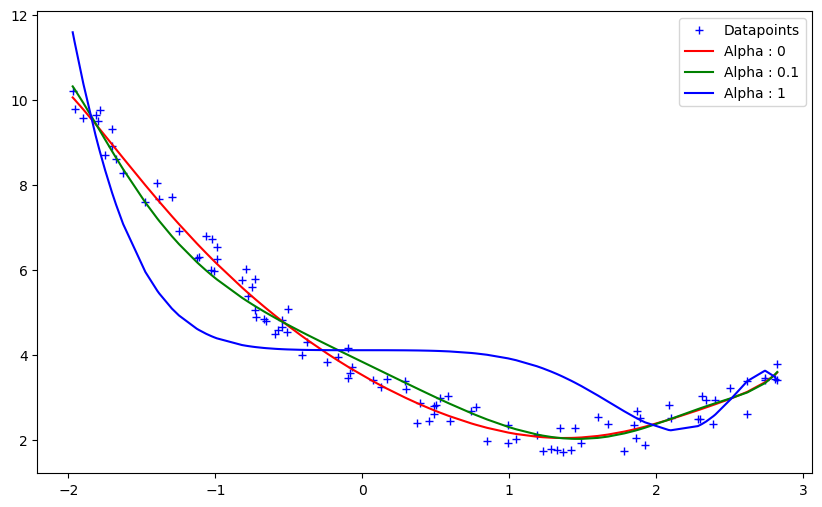

In [11]:
def get_pref_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree = 16)),
        ('lass', Lasso(alpha = alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0,0.1,1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10,6))
plt.plot(x1, x2, 'b+', label = 'Datapoints')

for alpha , c in zip(alphas, cs):
    preds = get_pref_lasso(x1, x2, alpha)

    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label = f'Alpha : {alpha}')

plt.legend()
plt.show()